# Exploratory Data Analysis on Winpower Sales and Billing System

### Project Introduction

##### This project analyzes a battery sales dataset containing customer transactions, invoice details, product sales, payment information, discounts, VAT, and delivery status.

##### The main objective is to discover:

- Sales trends
- Customer purchasing behavior
- Revenue performance
- Payment patterns
- Product demand
- Regional sales performance
- Return analysis

### Project Objectives
##### Main Objectives
- Analyze total sales revenue
- Find highest selling products
- Analyze payment behavior
- Detect sales trends over time
- Compare customer types
- Analyze regional sales performance
- Identify return patterns
- Evaluate discount impact on sales

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv('data/eda_dataset_winpower.csv')
df.columns

Index(['Billing_date', 'Invoice_id', 'Customer_id', 'Customer_name',
       'Customer_type', 'Sales_zone', 'Sales_id', 'Sales_person',
       'Product_code', 'Product_name', 'Battery_type', 'Quantity',
       'Unit_price_pcs', 'Amount', 'Discount_percent', 'Discount_amount',
       'VAT_amount', 'Sales_amount', 'Payment_status', 'Payment_method',
       'Region_manager', 'Delivery_date', 'Due_date', 'Return_status',
       'notes'],
      dtype='object')

#### Dataset Info

In [3]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Billing_date      5000 non-null   object 
 1   Invoice_id        5000 non-null   object 
 2   Customer_id       5000 non-null   object 
 3   Customer_name     5000 non-null   object 
 4   Customer_type     5000 non-null   object 
 5   Sales_zone        5000 non-null   object 
 6   Sales_id          5000 non-null   object 
 7   Sales_person      5000 non-null   object 
 8   Product_code      5000 non-null   object 
 9   Product_name      5000 non-null   object 
 10  Battery_type      5000 non-null   object 
 11  Quantity          5000 non-null   int64  
 12  Unit_price_pcs    5000 non-null   int64  
 13  Amount            5000 non-null   int64  
 14  Discount_percent  5000 non-null   int64  
 15  Discount_amount   5000 non-null   float64
 16  VAT_amount        5000 non-null   float64


,Billing_date,Invoice_id,Customer_id,Customer_name,Customer_type,Sales_zone,Sales_id,Sales_person,Product_code,Product_name,...,Discount_amount,VAT_amount,Sales_amount,Payment_status,Payment_method,Region_manager,Delivery_date,Due_date,Return_status,notes
0,2025-12-27,INV-10000,CUST-1002,Karim Battery House,Retail,Patuyakhali,S-108,Khairul Hasan,BT1022,Power Bank Battery,...,0.0,882.000,18522.000,Paid,Nagad,Shamim Ahmed,2025-12-29,2026-01-19,Not Returned,Let close defense.
1,2026-03-16,INV-10001,CUST-1013,Sadia Enterprise,Distributor,Barisal,S-106,Jahid Hasan,BT1013,Nickel Cadmium Battery,...,0.0,29.200,613.200,Paid,bKash,Nasir Uddin Ahmad,2026-03-20,2026-04-08,Not Returned,Soldier gas behind school part seek.
2,2025-10-04,INV-10002,CUST-1032,Rangpur Power House,Dealer,Sylhet,S-103,Sabbir Hossain,BT1009,Automotive Battery,...,1996.5,1896.675,39830.175,Paid,Nagad,Mahmud Hasan,2025-10-08,2025-10-21,Not Returned,Outside general drug yet.
3,2025-11-17,INV-10003,CUST-1017,Hasan & Brothers,Dealer,Rangpur,S-107,Rakibul Hasan,BT1016,Forklift Battery,...,0.0,255.300,5361.300,Paid,Bank Transfer,Mahmud Hasan,2025-11-19,2025-12-01,Not Returned,Improve store gas start media financial.
4,2026-04-30,INV-10004,CUST-1005,Dhaka Battery Point,Distributor,Pabna,S-109,Ruhul Amin,BT1004,Gel Battery,...,0.0,394.550,8285.550,Due,Bank Transfer,Yousuf Mazumder Anik,2026-05-01,2026-05-25,Not Returned,Professor network soldier star leader.


#### Missing Values

In [4]:
df.isnull().sum()

Billing_date        0
Invoice_id          0
Customer_id         0
Customer_name       0
Customer_type       0
Sales_zone          0
Sales_id            0
Sales_person        0
Product_code        0
Product_name        0
Battery_type        0
Quantity            0
Unit_price_pcs      0
Amount              0
Discount_percent    0
Discount_amount     0
VAT_amount          0
Sales_amount        0
Payment_status      0
Payment_method      0
Region_manager      0
Delivery_date       0
Due_date            0
Return_status       0
notes               0
dtype: int64

#### Convert Dates

In [5]:
date_cols = ['Billing_date', 'Delivery_date', 'Due_date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [6]:
# Dataset Shape

df.shape

(5000, 25)

In [7]:
# Statistical Summary


df.describe()

,Billing_date,Quantity,Unit_price_pcs,Amount,Discount_percent,Discount_amount,VAT_amount,Sales_amount,Delivery_date,Due_date
count,5000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000,5000
mean,2025-11-11 18:02:35.520000,15.286800,1633.297600,25355.347400,2.39040,600.074496,1237.763645,25993.036549,2025-11-14 18:02:00.960000,2025-11-30 07:11:42.720000
min,2025-05-14 00:00:00,1.000000,20.000000,54.000000,0.00000,0.000000,2.700000,56.700000,2025-05-15 00:00:00,2025-05-22 00:00:00
25%,2025-08-10 00:00:00,8.000000,641.000000,4740.000000,0.00000,0.000000,231.063000,4852.323000,2025-08-14 00:00:00,2025-08-30 00:00:00
50%,2025-11-09 00:00:00,15.000000,1279.000000,15520.500000,1.00000,0.870000,755.500000,15865.500000,2025-11-12 00:00:00,2025-11-27 00:00:00
75%,2026-02-15 00:00:00,23.000000,2029.000000,33023.250000,5.00000,558.800000,1617.912500,33976.162500,2026-02-18 00:00:00,2026-03-03 00:00:00
max,2026-05-14 00:00:00,30.000000,7990.000000,239610.000000,10.00000,22002.300000,11585.500000,243295.500000,2026-05-19 00:00:00,2026-06-12 00:00:00
std,NaN,8.612536,1543.447189,31353.151754,3.16177,1448.071402,1532.734091,32187.415904,NaN,NaN


In [8]:
# Duplicate Value Check

df.duplicated().sum()

0

In [9]:
# Total Sales Amount

total_sales = df['Sales_amount'].sum()

print("Total Sales:", total_sales)

Total Sales: 129965182.74599999


In [10]:
# Total VAT Amount

total_vat = df['VAT_amount'].sum()

print("Total VAT:", total_vat)

Total VAT: 6188818.226


In [11]:
# Total Discount Amount

total_discount = df['Discount_amount'].sum()

print("Total Discount:", total_discount)

Total Discount: 3000372.48


In [12]:
# Total Quantity Sold
df['Quantity'].sum()

76434

Product_name
Hybrid Vehicle Battery      1.477374e+07
Electric Bike Battery       1.354133e+07
Electric Scooter Battery    1.338246e+07
Forklift Battery            8.548172e+06
Industrial Battery          7.444854e+06
Solar Storage Battery       5.320017e+06
Power Bank Battery          5.095310e+06
Lithium-Ion Battery         4.756701e+06
Marine Battery              4.665639e+06
Laptop Battery Pack         4.461198e+06
Name: Sales_amount, dtype: float64


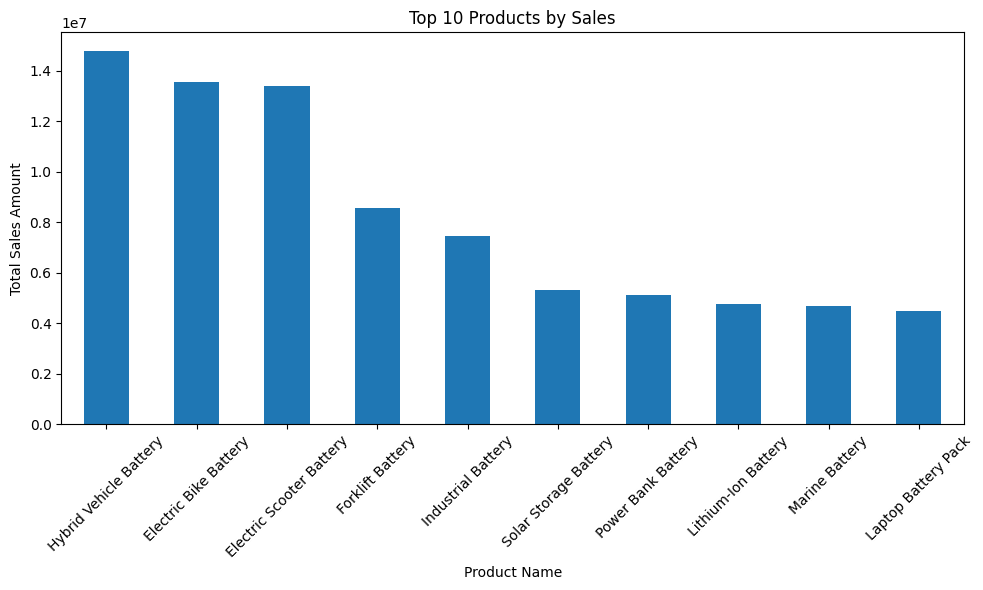

In [13]:
# Top 10 Products by Sales

top_products = df.groupby('Product_name')['Sales_amount'].sum().sort_values(ascending=False).head(10)
print(top_products)

top_products.plot(kind='bar', figsize=(10, 6))
plt.title('Top 10 Products by Sales')
plt.xlabel('Product Name')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Battery_type
AGM           2.843499e+06
Alkaline      6.637991e+05
Automotive    6.327109e+06
Deep Cycle    4.007182e+06
EV            4.169752e+07
Gel           3.524612e+06
Industrial    1.599303e+07
Lead Acid     7.034267e+06
Lithium       2.706571e+07
Marine        4.665639e+06
Medical       8.607040e+05
Motorcycle    2.377733e+06
NiCd          5.994117e+05
NiMH          7.539868e+05
Solar         5.320017e+06
UPS           6.230968e+06
Name: Sales_amount, dtype: float64


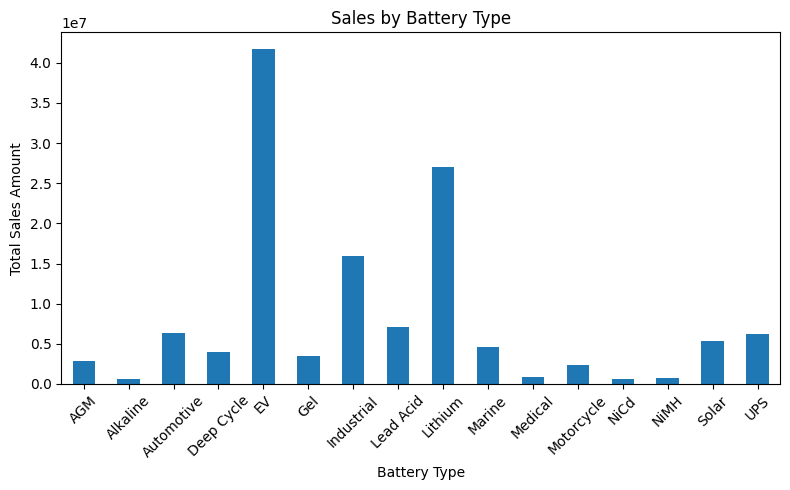

In [14]:
# Sales by Battery Type

battery_sales = df.groupby('Battery_type')['Sales_amount'].sum()
print(battery_sales)

battery_sales.plot(kind='bar', figsize=(8, 5))
plt.title('Sales by Battery Type')
plt.xlabel('Battery Type')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sales_zone
Rangpur        1.137670e+07
Habigonj       9.929448e+06
Rajshahi       9.903922e+06
Chattogram     9.886677e+06
Rajabari       9.787169e+06
Sylhet         9.506094e+06
Dhaka          9.482589e+06
Netrokuna      9.399355e+06
Patuyakhali    9.190100e+06
Barisal        8.466866e+06
Khulna         8.379708e+06
Pabna          8.288602e+06
Mymensingh     8.235836e+06
Bogura         8.132112e+06
Name: Sales_amount, dtype: float64


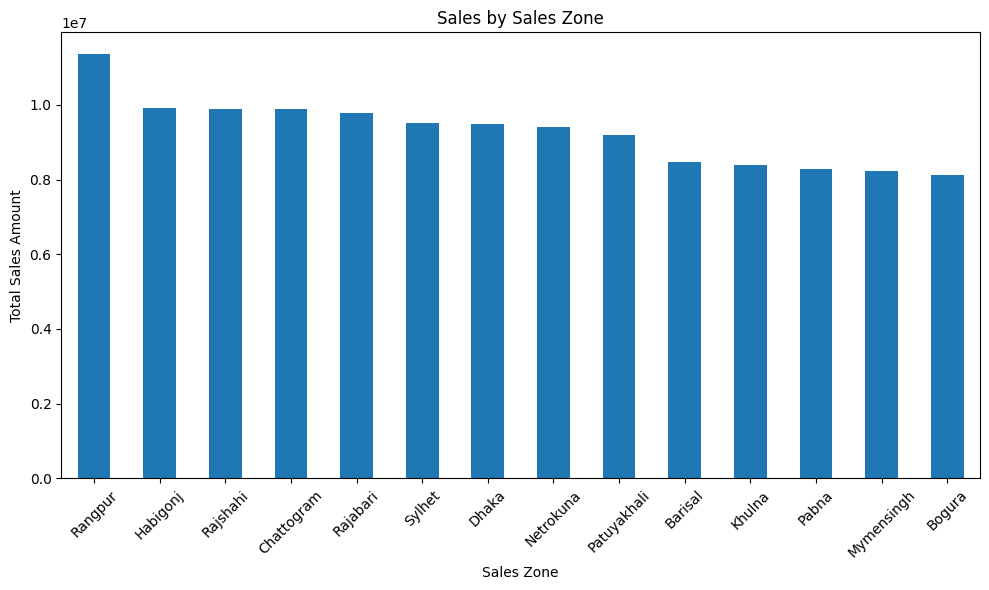

In [15]:
# Sales by Sales Zone

zone_sales = df.groupby('Sales_zone')['Sales_amount'].sum().sort_values(ascending=False)
print(zone_sales)

zone_sales.plot(kind='bar', figsize=(10, 6))
plt.title('Sales by Sales Zone')
plt.xlabel('Sales Zone')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Region_manager
Hasanuzzaman Helal      1.740574e+07
Omar Faruk              1.730219e+07
Nasir Uddin Ahmad       1.710896e+07
Yousuf Mazumder Anik    1.695434e+07
Rafiqul Islam           1.619525e+07
Mahmud Hasan            1.534923e+07
Shamim Ahmed            1.496025e+07
Mynuddin Hasan          1.468922e+07
Name: Sales_amount, dtype: float64


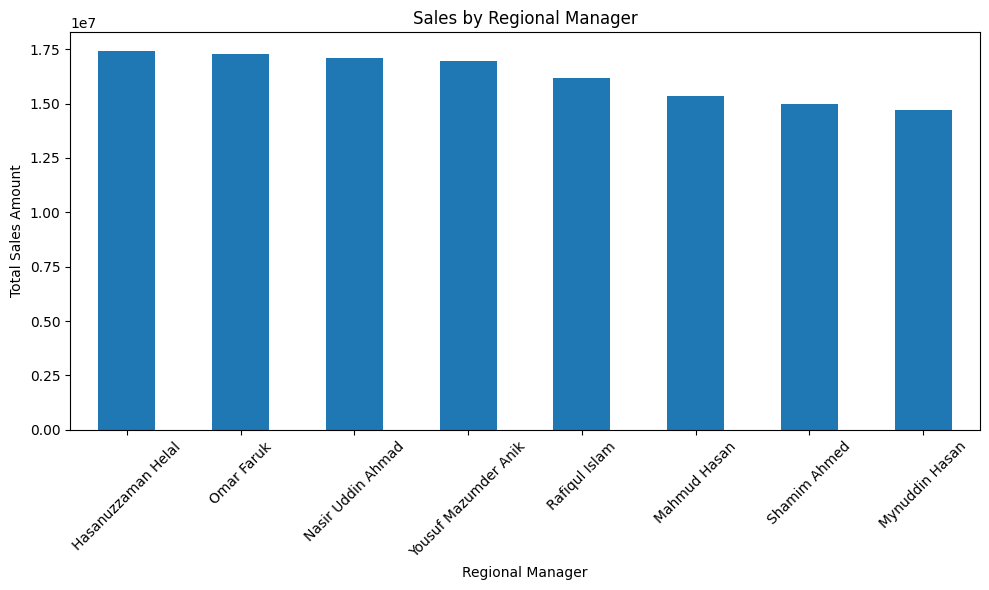

In [16]:
# Sales by Regional Manager

manager_sales = df.groupby('Region_manager')['Sales_amount'].sum().sort_values(ascending=False)
print(manager_sales)

manager_sales.plot(kind='bar', figsize=(10, 6))
plt.title('Sales by Regional Manager')
plt.xlabel('Regional Manager')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Payment Status Analysis

df['Payment_status'].value_counts()

Payment_status
Paid       3009
Partial    1215
Due         776
Name: count, dtype: int64

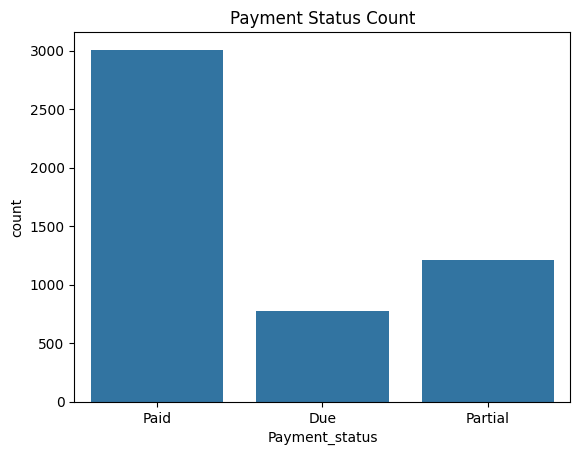

In [18]:
# Payment Status Visualization

sns.countplot(x='Payment_status', data=df)

plt.title("Payment Status Count")

plt.show()

#### Correlation Heatmap

In [19]:
# Payment Method Analysis

df['Payment_method'].value_counts()

Payment_method
Nagad            1287
bKash            1248
Bank Transfer    1236
Cash             1229
Name: count, dtype: int64

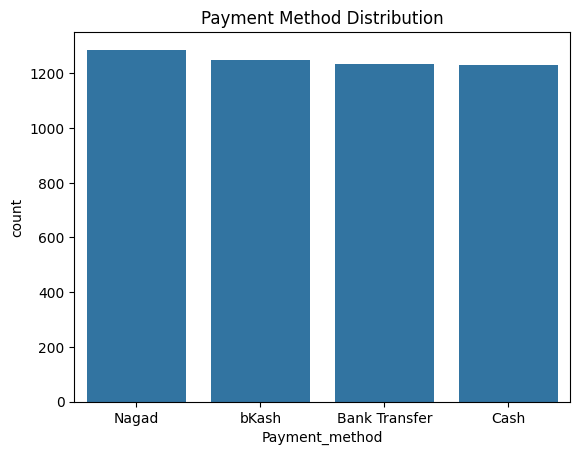

In [20]:
# Payment Method Visualization

sns.countplot(x='Payment_method', data=df)

plt.title("Payment Method Distribution")

plt.show()

Customer_type
Corporate      3.369469e+07
Dealer         2.986824e+07
Distributor    3.145540e+07
Retail         3.494686e+07
Name: Sales_amount, dtype: float64


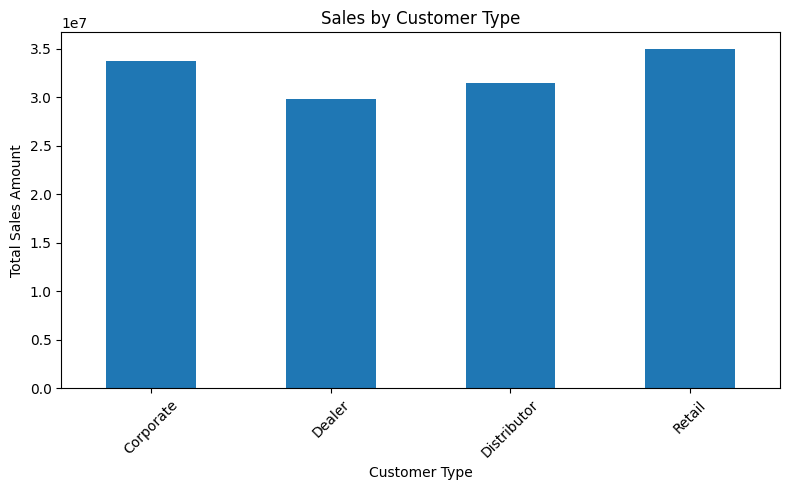

In [21]:
# Customer Type Sales Analysis

customer_sales = df.groupby('Customer_type')['Sales_amount'].sum()
print(customer_sales)

customer_sales.plot(kind='bar', figsize=(8, 5))
plt.title('Sales by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Billing_date
1     9.757209e+06
2     9.860532e+06
3     1.091623e+07
4     1.091013e+07
5     1.199362e+07
6     1.025640e+07
7     1.200343e+07
8     1.150213e+07
9     1.130433e+07
10    1.167782e+07
11    9.831260e+06
12    9.952096e+06
Name: Sales_amount, dtype: float64


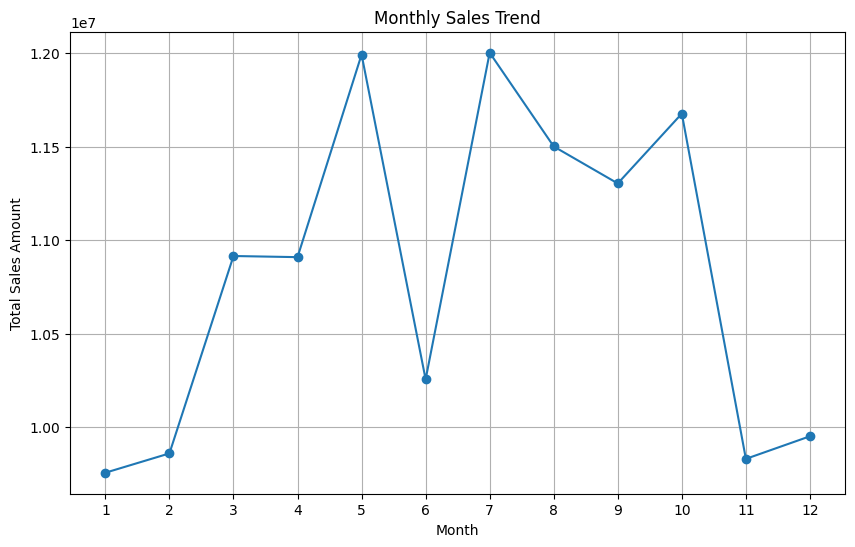

In [22]:
# Monthly Sales Trend

monthly_sales = df.groupby(df['Billing_date'].dt.month)['Sales_amount'].sum()
print(monthly_sales)

monthly_sales.plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.xticks(range(1, 13))
plt.grid()
plt.show()

Customer_name
Amin Battery Center         4.982893e+06
Dhaka Hot Power Solution    3.358912e+06
Noakhali Enterprise         3.297526e+06
M/S Battery World           3.075438e+06
City Battery Center         2.797693e+06
Rangpur Power House         2.753999e+06
Sumi Battery House          2.725427e+06
Future Energy BD            2.699415e+06
Nabil Enterprise            2.668979e+06
Sylhet Power Solution       2.629099e+06
Name: Sales_amount, dtype: float64


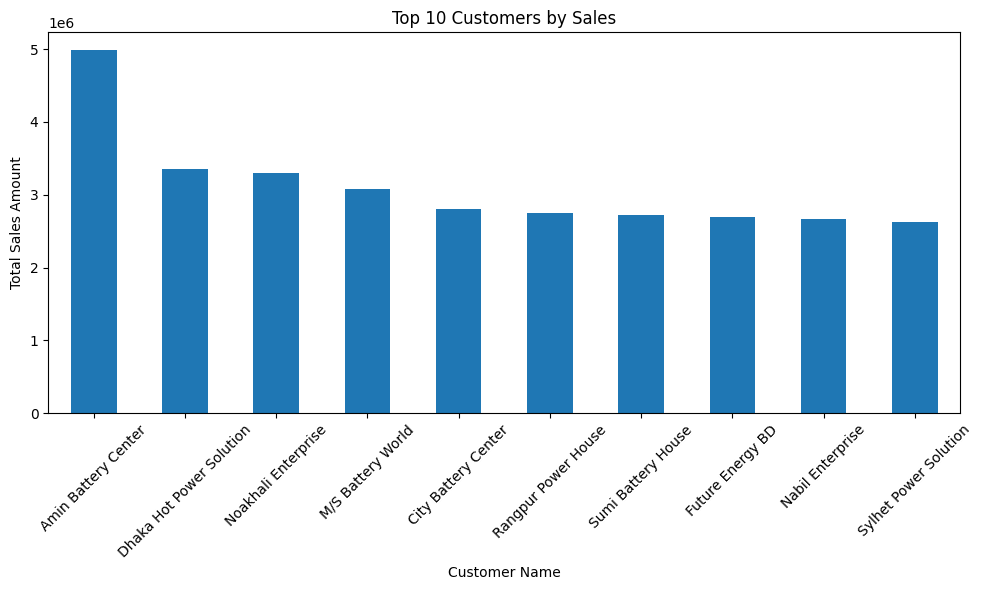

In [23]:
# Top 10 Customers

top_customers = df.groupby('Customer_name')['Sales_amount'].sum().sort_values(ascending=False).head(10)
print(top_customers)
top_customers.plot(kind='bar', figsize=(10, 6))
plt.title('Top 10 Customers by Sales')
plt.xlabel('Customer Name')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sales_person
Rakibul Hasan     1.137670e+07
Osman Faruk       9.929448e+06
Tanvir Rahman     9.903922e+06
Karim Hasan       9.886677e+06
Eyad Hossian      9.787169e+06
Sabbir Hossain    9.506094e+06
Rahim Ahmed       9.482589e+06
Alamgir Hossen    9.399355e+06
Khairul Hasan     9.190100e+06
Jahid Hasan       8.466866e+06
Nayeem Islam      8.379708e+06
Ruhul Amin        8.288602e+06
Shahriar Joy      8.235836e+06
Shamim Bepari     8.132112e+06
Name: Sales_amount, dtype: float64


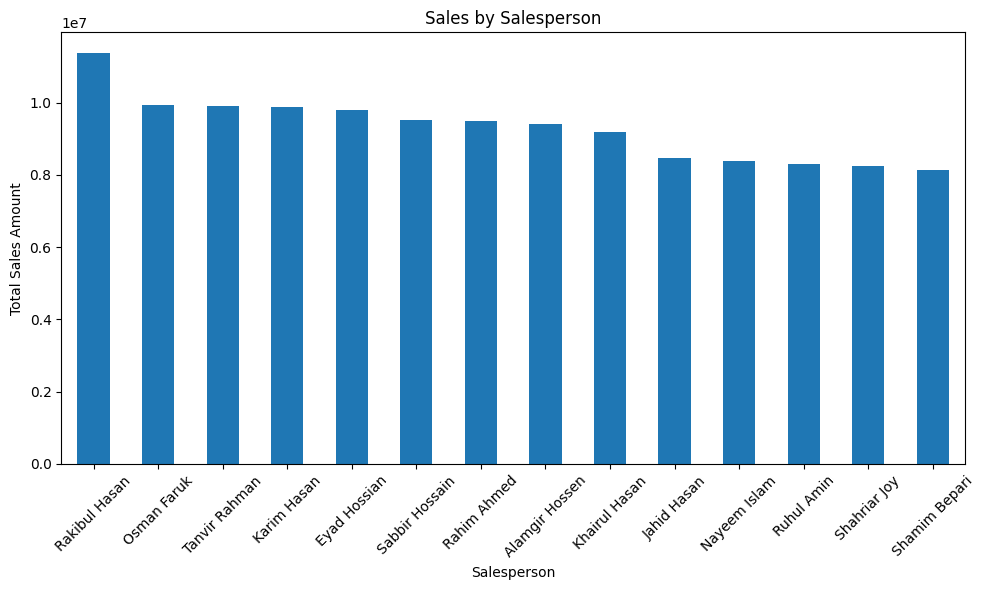

In [24]:
# Salesperson Performance

salesperson = df.groupby('Sales_person')['Sales_amount'].sum().sort_values(ascending=False)
print(salesperson)

salesperson.plot(kind='bar', figsize=(10, 6))
plt.title('Sales by Salesperson')
plt.xlabel('Salesperson')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# Return Status Analysis

df['Return_status'].value_counts()

Return_status
Not Returned    4481
Returned         519
Name: count, dtype: int64

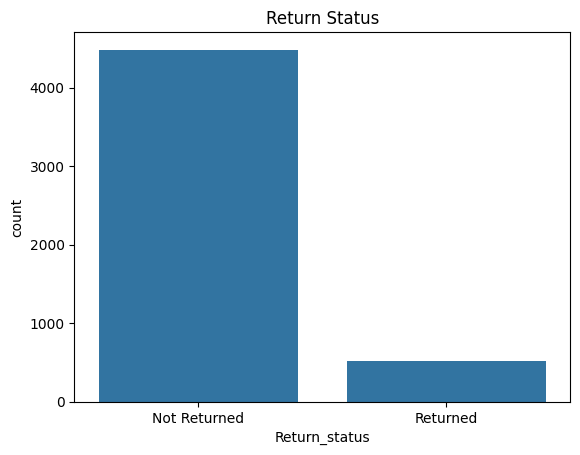

In [26]:
# Return Status Visualization

sns.countplot(x='Return_status', data=df)

plt.title("Return Status")

plt.show()

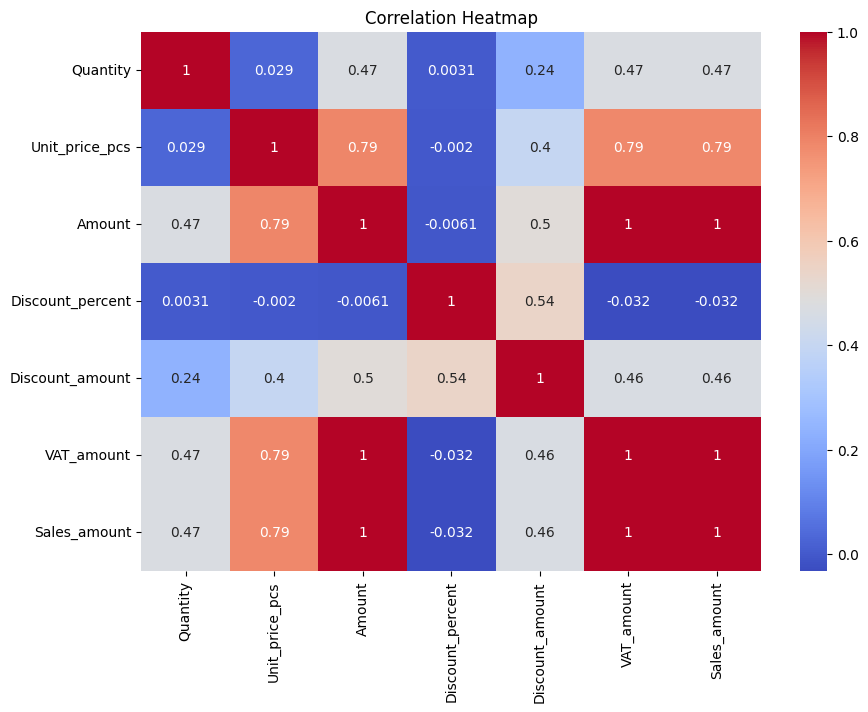

In [27]:
# Correlation Heatmap

numeric_cols = [
    'Quantity',
    'Unit_price_pcs',
    'Amount',
    'Discount_percent',
    'Discount_amount',
    'VAT_amount',
    'Sales_amount'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

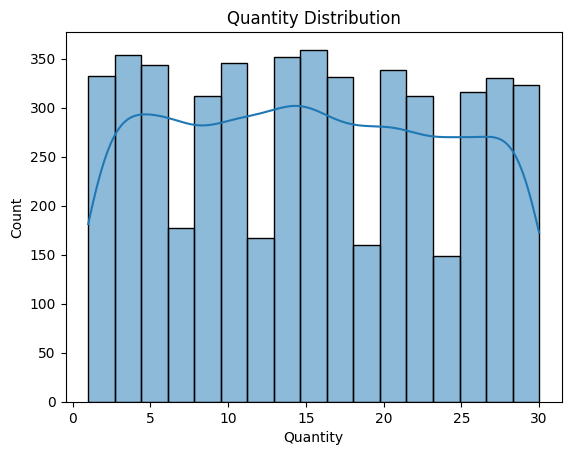

In [28]:
# Quantity Distribution

sns.histplot(df['Quantity'], kde=True)

plt.title("Quantity Distribution")

plt.show()

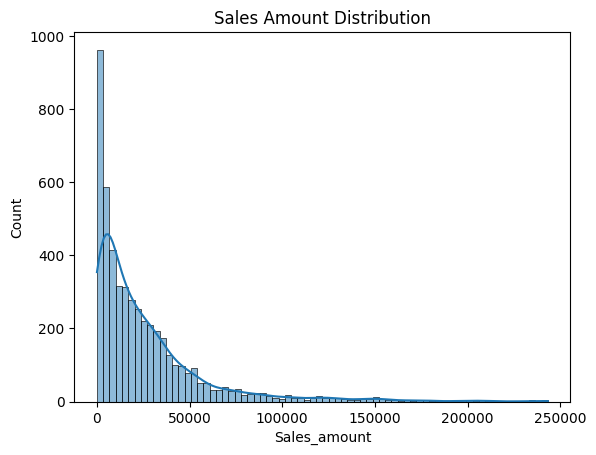

In [29]:
# Sales Amount Distribution

sns.histplot(df['Sales_amount'], kde=True)

plt.title("Sales Amount Distribution")

plt.show()

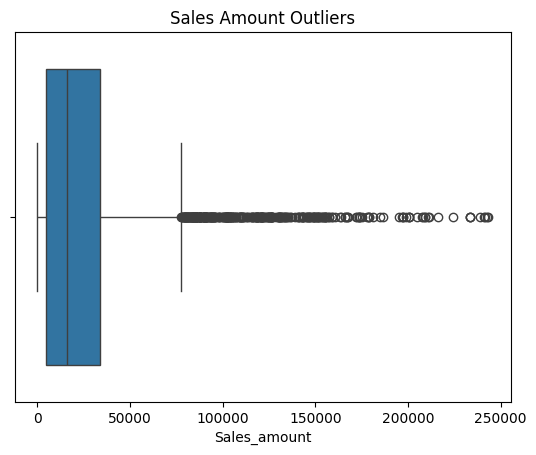

In [30]:
# Boxplot for Outlier Detection

sns.boxplot(x=df['Sales_amount'])

plt.title("Sales Amount Outliers")

plt.show()

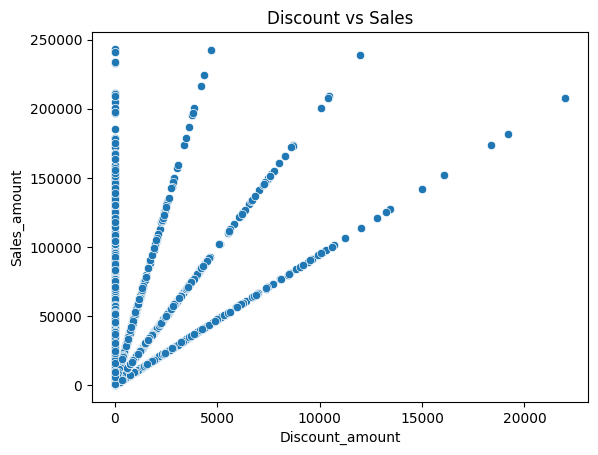

In [31]:
# Discount vs Sales Scatter Plot

sns.scatterplot(
    x='Discount_amount',
    y='Sales_amount',
    data=df
)

plt.title("Discount vs Sales")

plt.show()

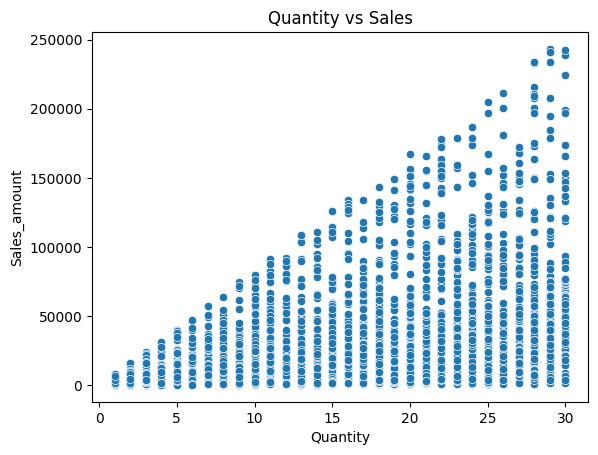

In [32]:
# Quantity vs Sales Scatter Plot

sns.scatterplot(
    x='Quantity',
    y='Sales_amount',
    data=df
)

plt.title("Quantity vs Sales")

plt.show()

In [33]:
# Average Sales Per Invoice

avg_invoice = df.groupby('Invoice_id')['Sales_amount'].sum().mean()

print("Average Invoice Sales:", avg_invoice)

Average Invoice Sales: 25993.0365492


In [34]:
# Average Delivery Days

df['Delivery_Days'] = (
    df['Delivery_date'] - df['Billing_date']
).dt.days

df['Delivery_Days'].mean()

2.9996

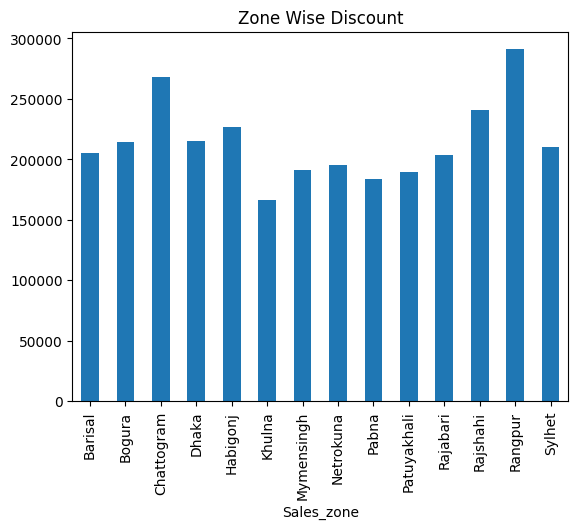

In [35]:
#  Zone Wise Discount

zone_discount = df.groupby('Sales_zone')['Discount_amount'].sum()

zone_discount.plot(kind='bar')

plt.title("Zone Wise Discount")

plt.show()

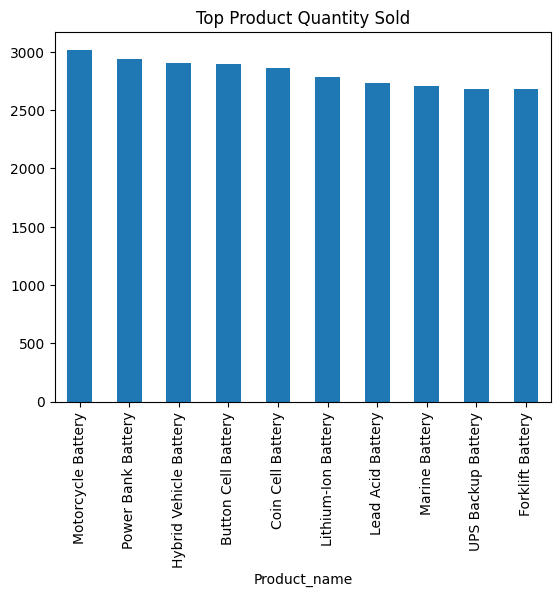

In [36]:
#  Product Wise Quantity Sold

product_qty = df.groupby('Product_name')['Quantity'].sum().sort_values(ascending=False).head(10)

product_qty.plot(kind='bar')

plt.title("Top Product Quantity Sold")

plt.show()

In [37]:
# Final KPI Summary

print("========== KPI SUMMARY ==========")

print("Total Sales:", df['Sales_amount'].sum())
print("Total VAT:", df['VAT_amount'].sum())
print("Total Discount:", df['Discount_amount'].sum())
print("Total Quantity:", df['Quantity'].sum())
print("Average Sales:", df['Sales_amount'].mean())
print("Total Customers:", df['Customer_id'].nunique())
print("Total Products:", df['Product_name'].nunique())
print("Total Invoices:", df['Invoice_id'].nunique())

========== KPI SUMMARY ==========
Total Sales: 129965182.74599999
Total VAT: 6188818.226
Total Discount: 3000372.48
Total Quantity: 76434
Average Sales: 25993.0365492
Total Customers: 59
Total Products: 30
Total Invoices: 5000
